In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

#  A sample sales dataset (200 records) with columns: order_id, customer_age, city, category, quantity, unit_price, rating, date
np.random.seed(42)
n = 200

data = {
    'order_id': range(1, n+1),
    'customer_age': np.random.randint(18, 65, n),
    'city': np.random.choice(['Kitwe', 'Lusaka', 'Ndola', 'Livingstone','Chingola'], n),
    'category': np.random.choice(['Electronics', 'Clothing', 'Food', 'Toys','gaming'], n),
    'quantity': np.random.randint(1, 10, n),
    'unit_price': np.round(np.random.uniform(5, 200, n), 2),
    'rating': np.random.choice([1,2,3,4,5, np.nan], n),
    'date': pd.date_range('2023-01-01', periods=n, freq='2D')
}

df = pd.DataFrame(data) # data frame converts the dictionary into pandas (tables)


bad_rows=df['unit_price'] < 0
num_fixed = bad_rows.sum()

print(f"Found {num_fixed} rows with negative unit_price")

median_price=df['unit_price'].median()

df.loc[bad_rows, 'unit_price'] = median_price



df['total_sales'] = df['quantity'] * df['unit_price']

print(f"\n Successfully fixed {num_fixed} rows with negative unit prices.")
print(f"New unit price range: {df['unit_price'].min():.2f} to {df['unit_price'].max():.2f}")
print(f"New total_sales range: {df['total_sales'].min():.2f} to {df['total_sales'].max():.2f}")

# Final verification
print(f"Negative unit prices remaining: {(df['unit_price'] < 0).sum()}")

print('Dataset loaded! Shape:', df.shape)
df.head()

Found 0 rows with negative unit_price

 Successfully fixed 0 rows with negative unit prices.
New unit price range: 5.90 to 198.04
New total_sales range: 15.68 to 1676.07
Negative unit prices remaining: 0
Dataset loaded! Shape: (200, 9)


,order_id,customer_age,city,category,quantity,unit_price,rating,date,total_sales
0,1,56,Lusaka,Food,2,52.28,1.0,2023-01-01,104.56
1,2,46,Ndola,Toys,4,57.50,5.0,2023-01-03,230.00
2,3,32,Kitwe,Clothing,8,78.57,3.0,2023-01-05,628.56
3,4,60,Chingola,Clothing,9,8.91,NaN,2023-01-07,80.19
4,5,25,Kitwe,gaming,7,67.81,2.0,2023-01-09,474.67


In [ ]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

# Fix: fill missing age with median
df['customer_age'].fillna(df['customer_age'].median())

#Clean code
df['rating'].fillna(df['rating'].median())

print('\nAfter fixing:')
print(df.isnull().sum())

Missing values per column:
order_id         0
customer_age     0
city             0
category         0
quantity         0
unit_price       0
rating          35
date             0
total_sales      0
dtype: int64

After fixing:
order_id         0
customer_age     0
city             0
category         0
quantity         0
unit_price       0
rating          35
date             0
total_sales      0
dtype: int64


---
## Exploratory Analysis (EDA)
> Understand the data — who buys what, where, and how much?

In [ ]:
# Basic stats
print('=== Summary Statistics ===')
print(df[['customer_age', 'unit_price', 'quantity', 'total_sales']].describe())

# Sales by category
print('\n=== Total Sales by Category ===')
print(df.groupby('category')['total_sales'].sum().sort_values(ascending=False))

# Average rating by category
print('\n=== Avg Rating by Category ===')
print(df.groupby('category')['rating'].mean().round(2))

=== Summary Statistics ===
       customer_age  unit_price    quantity  total_sales
count    200.000000  200.000000  200.000000   200.000000
mean      41.570000  101.482650    4.730000   483.524600
std       13.715527   54.703903    2.619429   407.135722
min       18.000000    5.900000    1.000000    15.680000
25%       30.000000   53.335000    2.000000   160.007500
50%       42.000000  100.500000    5.000000   337.435000
75%       54.000000  149.657500    7.000000   666.225000
max       64.000000  198.040000    9.000000  1676.070000

=== Total Sales by Category ===
category
Clothing       23481.45
gaming         22799.54
Food           18013.92
Toys           16602.80
Electronics    15807.21
Name: total_sales, dtype: float64

=== Avg Rating by Category ===
category
Clothing       2.79
Electronics    2.78
Food           3.48
Toys           2.85
gaming         3.02
Name: rating, dtype: float64


In [ ]:
# A city with a highest total sales

# Get month name instead of number (more readable for charts)
df['month_name'] = df['date'].dt.month_name()

# Get abbreviated month name
df['month_abbr'] = df['date'].dt.strftime('%b')   # Jan, Feb, Mar...

# Get year-month combination (useful for time series)
df['year_month'] = df['date'].dt.to_period('M')


---
Visualization


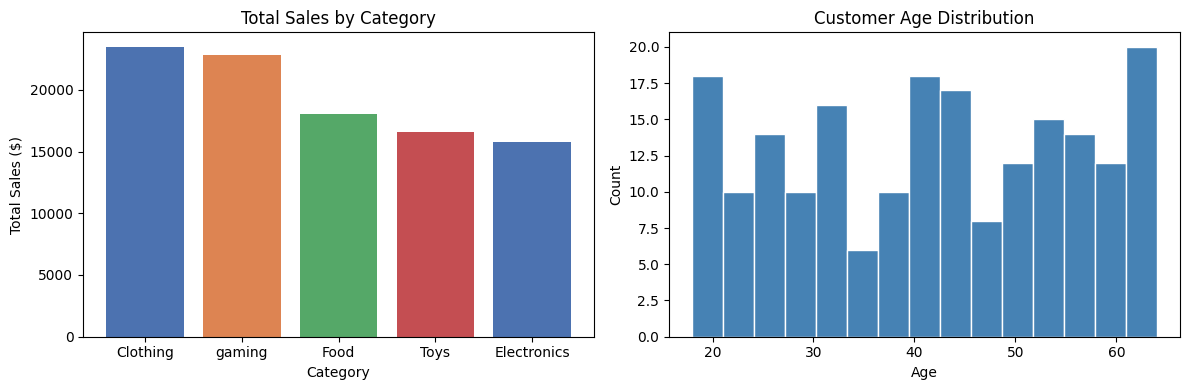

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: Sales by category
sales_by_cat = df.groupby('category')['total_sales'].sum().sort_values(ascending=False)
axes[0].bar(sales_by_cat.index, sales_by_cat.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales ($)')

# Histogram: Customer age distribution
axes[1].hist(df['customer_age'], bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('Customer Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


Create a figure with **3 charts** side by side:
1. **Bar chart** — Total sales by city
2. **Pie chart** — Order count share by category (use `plt.pie()`)
3. **Line chart** — Monthly total sales over time


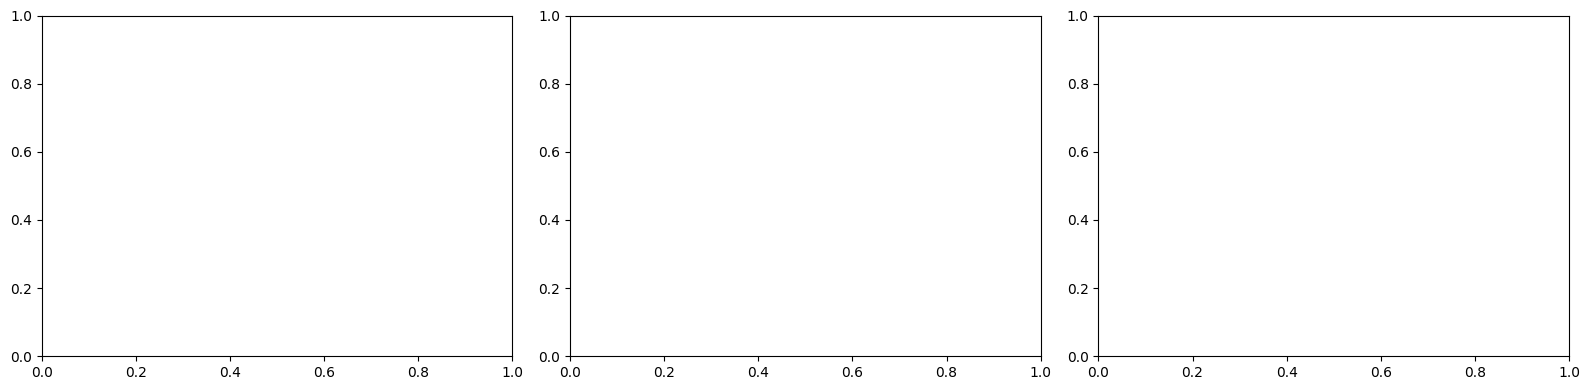

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Sales by city
# ...

# Chart 2: Order count by category (pie)
# ...

# Chart 3: Monthly sales line chart
# ...

plt.tight_layout()
plt.show()

---
# ML Modeling (Linear Regression)
> Goal: Predict total sales based on quantity, price, and age.

#Train and evaluate a model

In [ ]:
# Encode categorical columns
le = LabelEncoder()
df['city_enc'] = le.fit_transform(df['city'])
df['category_enc'] = le.fit_transform(df['category'])

# Features and target
features = ['quantity', 'unit_price', 'customer_age', 'city_enc', 'category_enc']
X = df[features]
y = df['total_sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² Score: {r2_score(y_test, y_pred):.3f}')
print(f'RMSE: {rmse:.2f}')

# Feature importance
print('\nFeature Coefficients:')
for f, c in zip(features, model.coef_):
    print(f'  {f}: {c:.3f}')

R² Score: 0.888
RMSE: 151.12

Feature Coefficients:
  quantity: 106.125
  unit_price: 4.394
  customer_age: 0.956
  city_enc: 3.359
  category_enc: 3.024
